# NOTEBOOK NAME
Created by: Thomas Durand-Texte, 2023

# Import des packages et données
## import des packages

In [1]:
import os

import pandas as pd
import numpy as np
# import dask as dd
pd.set_option("display.max_columns", 200)
import datetime as dt
import scipy.stats as st

from sklearn import model_selection, metrics, preprocessing


import matplotlib.pyplot as plt
import seaborn as sns

cm = 1./2.54

## Paramètres graphiques et fonctions utiles

In [2]:
import subprocess

white_font = True
def set_theme( white_font=True ):
    """ set_theme( white_font=True ) """
    if white_font: wht, grey, blck = '0.84' , '0.5', 'k'
    else: wht, grey, blck = 'k', '0.5', '0.84'
    rc = { 'figure.facecolor':(0.118,)*3,
            'axes.labelcolor':wht,
            'axes.edgecolor':wht,
            'axes.facecolor':(0,0,0,0),
            'text.color':'white',
            'text.usetex':False,
            'text.latex.preamble':r'\usepackage[cm]{sfmath} \usepackage{amsmath}' ,
            'font.family': 'sans-serif' ,
            'font.sans-serif': 'DejaVu Sans' ,
            'xtick.color':wht,
            'ytick.color':wht,
            "axes.grid" : True,
            "grid.color": (0.7,)*3,
            "grid.linewidth": 0.4,
            "grid.linestyle": (10,5),
            'legend.edgecolor':'0.2',
            'legend.facecolor':(0.2,0.2,0.2,0.6),
            # 'legend.framealpha':'0.6',
            'pdf.fonttype':42,
            'savefig.format':'pdf',
            'savefig.transparent':True,
            'figure.dpi':150, # for better agreemet figsize vs real size
        }

    sns.set_theme( 'notebook' , rc=rc )
    return


def make_folder( path_folder ):
    path_folder = path_folder.__str__()
    try:
        if os.path.isdir( path_folder ) : return
        os.makedirs(path_folder)
    except OSError:
        pass
    return

def concat_folders(*args, **kwargs):
    """ concat_folders(*args, **kwargs)
        concatenate folders in args (strings) """
    sPath = ''
    for arg in args:
        if arg == '..': sPath = sPath[:sPath[:-1].rfind(os.sep)+1]
        else: sPath += arg
        if sPath[-1] != os.sep: sPath += os.sep
    return sPath

class Path(object):
    """ Path( s_in='', s_lim=None)
        create a path to the string s_in (default is current path)
        and stops after s_lim """
    n_Path = 0
    def __init__(self, s_in='', s_lim=None):
        """docstring."""
        if s_in == '': s_in = os.getcwd()
        if not s_lim is None:
            if s_lim in s_in:
                s_in = s_in[ :s_in.index( s_lim ) + len(s_lim) ]
        self.sPath = concat_folders(s_in)
        self.N = Path.n_Path
        Path.n_Path += 1

    def __add__(self, other):
        """ Path + str : return str """
        if isinstance(other, str): return self.sPath + other

    def __truediv__(self, other):
        """ Path / str : return path concatenated"""
        if isinstance(other, str): return Path(concat_folders(self.sPath, other))

    def __invert__(self):
        """ ~Path : return str of the path """
        return self.sPath

    def __str__(self):
        """ __str__ return str of the path """
        return self.sPath
    # __str__ #

    def makedir( self ):
        return make_folder( self )


def gs_opt( filename ):
    """ otpimisation of a pdf file with gosthscript """
    filenameTmp = filename.replace('.pdf', '') + '_tmp.pdf'
    gs = ['gs',
            '-sDEVICE=pdfwrite',
            '-dEmbedAllFonts=true',
            '-dSubsetFonts=true',             # Create font subsets (default)
            '-dPDFSETTINGS=/prepress',        # Image resolution
            '-dDetectDuplicateImages=true',   # Embeds images used multiple times only once
            '-dCompressFonts=true',           # Compress fonts in the output (default)
            '-dNOPAUSE',                      # No pause after each image
            '-dQUIET',                        # Suppress output
            '-dBATCH',                        # Automatically exit
            '-sOutputFile='+filenameTmp,      # Save to temporary output
            filename]                         # Input file

    subprocess.run(gs)                                      # Create temporary file
    subprocess.run( 'rm -f ' + filename, shell=True)            # Delete input file
    subprocess.run( 'mv -f ' + filenameTmp + " " + filename, shell=True) # Rename temporary to input file

def savefig( fig, savename, **kwargs ):
    """ savefig( fig, savename, **kwargs )
        Saves a figure with kwargs (fig.savefig( savename, **kwargs) ).
        A check is done first to determine if a folder has to be created according to savename.
        Finally, if the file is saved as .pdf, gosthscript optimisation is performed. """
    if os.sep in savename: make_folder( savename[:savename.rindex(os.sep)] )
    fig.savefig( savename, **kwargs )
    savename += '.pdf'
    if os.path.isfile( savename ): gs_opt( savename )


def image_size_from_width_and_shape( width: float, shape: tuple, ymargin=0. ):
    """ return tuple (width, height) corresponding to image shape """
    return width, width*shape[0]/shape[1]+ymargin

def image_size_from_height_and_shape( height: float, shape: tuple, xmargin=0. ):
    """ return tuple (width, height) corresponding to image shape """
    return height*shape[1]/shape[0]+xmargin, height


set_theme()
del set_theme

## Chargement des données

Affichage de l'arborescence

In [3]:
def print_listdir( path=None, level=0, exclude=[] ) :
    suffix = ''
    if level > 0:
        suffix = ' |-'* level
    vals = os.listdir( path )
    vals.sort()
    if path is None:
        path = ''
    for val in vals:
        if val in exclude: continue
        print( suffix, val)
        if os.path.isdir( path + val):
            print_listdir( path + val + '/', level+1 )

print_listdir( exclude=['.venv', 'ressources', 'devel'] )

 data
 |- cleaned
 |- data_diagram.png
 |- data_diagram_resized.png
 |- source
 |- |- olist_customers_dataset.csv
 |- |- olist_customers_dataset.csv.zip
 |- |- olist_geolocation_dataset.csv
 |- |- olist_geolocation_dataset.csv.zip
 |- |- olist_order_items_dataset.csv
 |- |- olist_order_items_dataset.csv.zip
 |- |- olist_order_payments_dataset.csv
 |- |- olist_order_payments_dataset.csv.zip
 |- |- olist_order_reviews_dataset.csv
 |- |- olist_order_reviews_dataset.csv.zip
 |- |- olist_orders_dataset.csv
 |- |- olist_orders_dataset.csv.zip
 |- |- olist_products_dataset.csv
 |- |- olist_products_dataset.csv.zip
 |- |- olist_sellers_dataset.csv
 |- |- product_category_name_translation.csv
 install_packages_venv.sh
 notebook.ipynb


Chargement / compression des données

In [4]:
path = 'data/source/'

filenames = ['customers', 'geolocation', 'orders', 'order_items', 'order_payments', 'order_reviews', 'products', 'sellers']
dfs = { filename: pd.read_csv( path + f'olist_{filename}_dataset' + '.csv' ) for filename in filenames }
filename = 'product_category_name_translation'
dfs[filename] = pd.read_csv( path + filename + '.csv')

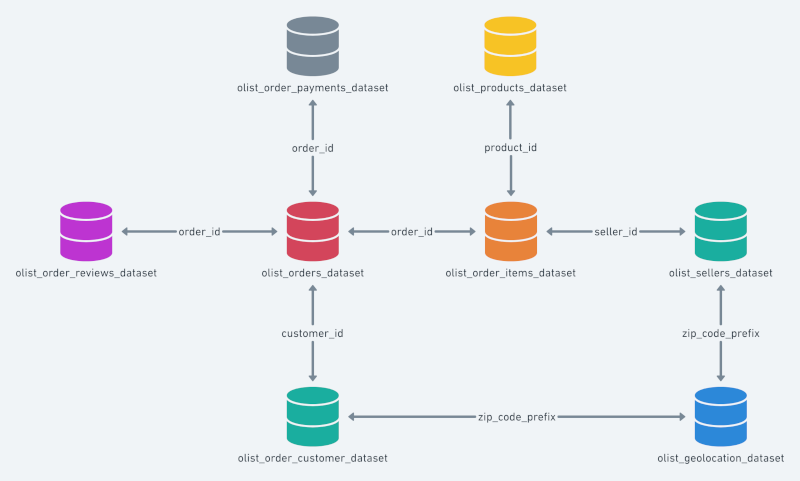

In [5]:
for filename, df_tmp in dfs.items():
    print(filename)
    display( df_tmp.sample(5) )
    print('\n\n')

customers


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
5924,aca0989af736e8b434d68e6f38e50739,2c9531c3d00dcaeca5479e56b884ec34,36025,juiz de fora,MG
23584,e89cd2c49972d182f0fb9deb845ccf62,175e07edc5bf8b165844765acc6f1645,3203,sao paulo,SP
78809,a17846ed33d62b0e48c6f07ce9132318,43eb0e993502bd4cbd3400a492a5444d,37600,cambui,MG
33781,18d46e1e396620d92cc0acbf564fd572,d5ffb01a18220bff913bad2291a54772,21842,rio de janeiro,RJ
88415,bb514cf4c072f5b604be110df9585d95,e58c0f78a7e98fbed6df464265855d37,13275,valinhos,SP





geolocation


,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
299959,13218,-23.190440,-46.869730,jundiai,SP
207272,8597,-23.462032,-46.310611,itaquaquecetuba,SP
946733,91180,-30.014516,-51.110168,porto alegre,RS
5154,1201,-23.534834,-46.648684,sao paulo,SP
580157,33823,-19.761851,-44.146658,ribeirao das neves,MG





orders


...

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
32810,3eb3d83d082ce242d4eae1f57e62640d,alimentos_bebidas,30.0,355.0,2.0,300.0,25.0,9.0,18.0
4793,5cc37c2c2b8ea0c98010d1ee6028e45b,eletroportateis,59.0,2212.0,4.0,8700.0,40.0,16.0,40.0
13845,616c1294c57a15354902fb69420fdc2f,moveis_decoracao,63.0,389.0,1.0,1400.0,45.0,15.0,35.0
11362,a1d7fd9726f3447e898828befde19e11,moveis_decoracao,48.0,1750.0,3.0,2550.0,105.0,3.0,70.0
28084,d02df257dbc6857326ebdb3ffc3d6848,esporte_lazer,56.0,261.0,2.0,800.0,60.0,15.0,15.0





sellers


,seller_id,seller_zip_code_prefix,seller_city,seller_state
462,6a51fc556dab5f766ced6fbc860bc613,17500,marilia,SP
2978,5415337f1863452476d42d9f14a16a61,30840,belo horizonte,MG
2577,5882f40daf39bc2a465e0cb453ddc222,5616,sao paulo,SP
2904,f4ce8ca9fa7157e3b33f536ac9a4487d,16306,penapolis,SP
1601,08d0949a9a17c027262db1f3c450c26c,85804,cascavel,PR





product_category_name_translation


,product_category_name,product_category_name_english
30,moveis_escritorio,office_furniture
10,alimentos_bebidas,food_drink
66,flores,flowers
41,instrumentos_musicais,musical_instruments
69,fashion_roupa_infanto_juvenil,fashion_childrens_clothes


RFM:

|  |  |
| :--- | :--- |
| Récence | Nombre de jours depuis le dernier achat |
| Fréquence | Nombre de commandes |
| Montant | Montant total des achats |

Looking at monetary divided by frequency indicates the average purchase amount – an important secondary factor to consider when segmenting customers.

* groupby + agg
* Faire une PCA (inclure cercle de corrélation)
* modéliser
* Passer du temps à analyser les clusters
* Ajouter queques features
    * review score moyen ?
    * date livraison - date achat
    * retard de livraison / % retard livraison
    * type de payment

* Regarder la maintenance


In [6]:
df = dfs['customers']
print('custormers :', df.shape)
display( df.head() )

df.info()

print('customer_id :', df['customer_id'].value_counts().shape )
print('customer_unique_id :', df['customer_unique_id'].value_counts().shape )

custormers : (99441, 5)


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB
customer_id : (99441,)
customer_unique_id : (96096,)


Pour le dataset "orders":

99 441 entrées:
- order_delivered_carrier_date   97658 non-null  object
- order_delivered_customer_date  96476 non-null  object


In [7]:
df = dfs['orders']
print('orders :', df.shape)
display( df.head() )

df.info()

key = 'order_status'
df[key].value_counts( normalize=True )

orders : (99441, 8)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


delivered      0.970203
shipped        0.011132
canceled       0.006285
unavailable    0.006124
invoiced       0.003158
processing     0.003027
created        0.000050
approved       0.000020
Name: order_status, dtype: float64

In [9]:
df = dfs['order_payments']
print('order_payments :', df.shape)
display( df.head() )

df.info()

order_payments : (103886, 5)


,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              103886 non-null  object 
 1   payment_sequential    103886 non-null  int64  
 2   payment_type          103886 non-null  object 
 3   payment_installments  103886 non-null  int64  
 4   payment_value         103886 non-null  float64
dtypes: float64(1), int64(2), object(2)
memory usage: 4.0+ MB


In [10]:
df_merged = dfs['orders'].merge(dfs['customers'], how='left', on='customer_id')
df_merged = df_merged.merge( dfs['order_payments'], how='left', on='order_id' )

df_merged.sample(5)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,payment_sequential,payment_type,payment_installments,payment_value
55438,db0b12b763f716df3f27218724161479,84670f973f394ff5609861af7d0157ae,delivered,2017-01-20 19:22:40,2017-01-20 19:31:22,2017-01-23 11:29:09,2017-01-25 17:17:57,2017-02-28 00:00:00,c133266c3fa2b7e61977e256dec074a0,82120,curitiba,PR,1.0,credit_card,5.0,497.74
81963,88a385737ede49900eeccbcd1d16fa00,5e1d72bbaa87d25e9c72e387b86b5a05,delivered,2017-02-15 12:56:00,2017-02-15 13:10:39,2017-02-16 08:07:19,2017-03-02 15:07:27,2017-03-20 00:00:00,7e7301841ddb4064c2f3a31e4c154932,24744,sao goncalo,RJ,1.0,credit_card,1.0,117.44
54500,0410f4cc1616cb8c9d1f03c78a8c9f81,cb3ac9287a240ab1ff177d10e4f61553,delivered,2017-06-22 22:31:14,2017-06-22 22:43:15,2017-06-26 17:22:56,2017-07-11 20:16:25,2017-07-26 00:00:00,e7186ccfd4b94f9bec13a341d33b79d3,50870,recife,PE,1.0,credit_card,4.0,86.46
30839,b782d486ebb05fdf0ba6ec05652f704f,3afe43b81b0d102b2ca5138ab53f418a,delivered,2017-01-26 16:29:30,2017-01-28 02:32:24,2017-02-01 08:37:30,2017-02-06 14:23:54,2017-03-02 00:00:00,15fbc48df691e0ad51b0cf30d86392a2,4609,sao paulo,SP,1.0,boleto,1.0,1837.16
96381,0c1131dcb8c6ec0c895af6aea3e70983,69de6e98cbd456c73122e8fd3a20554d,delivered,2018-03-04 01:19:17,2018-03-05 04:15:31,2018-03-15 18:33:42,2018-04-24 15:42:11,2018-04-13 00:00:00,91d5da8c24686b483a7b08bfddf5c344,60714,fortaleza,CE,1.0,credit_card,4.0,218.10


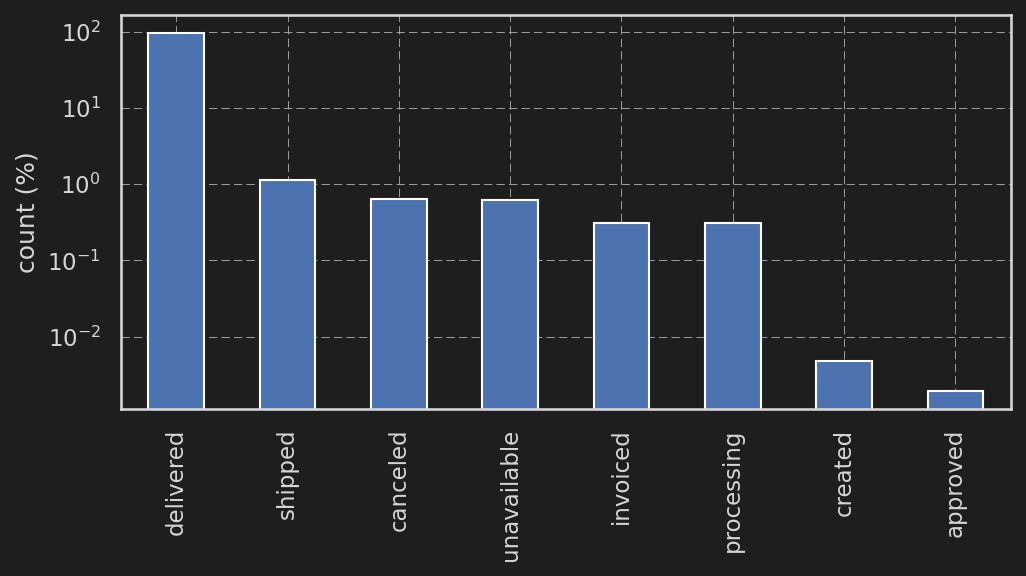

In [11]:
fig, ax = plt.subplots( figsize=(7,4))
(df_merged['order_status'].value_counts( normalize=True )*100).plot( kind='bar', logy=True, ax=ax )
ax.set_ylabel('count (%)')
fig.tight_layout()

In [12]:
timestamp_cols = ['order_purchase_timestamp', 'order_approved_at',
                    'order_delivered_carrier_date', 'order_delivered_customer_date',
                    'order_estimated_delivery_date']
for col in timestamp_cols:
    df_merged[col] = pd.to_datetime(df_merged[col])

In [14]:
df_merged['order_purchase_timestamp'].dt.year.value_counts()

2018    56015
2017    47525
2016      347
Name: order_purchase_timestamp, dtype: int64

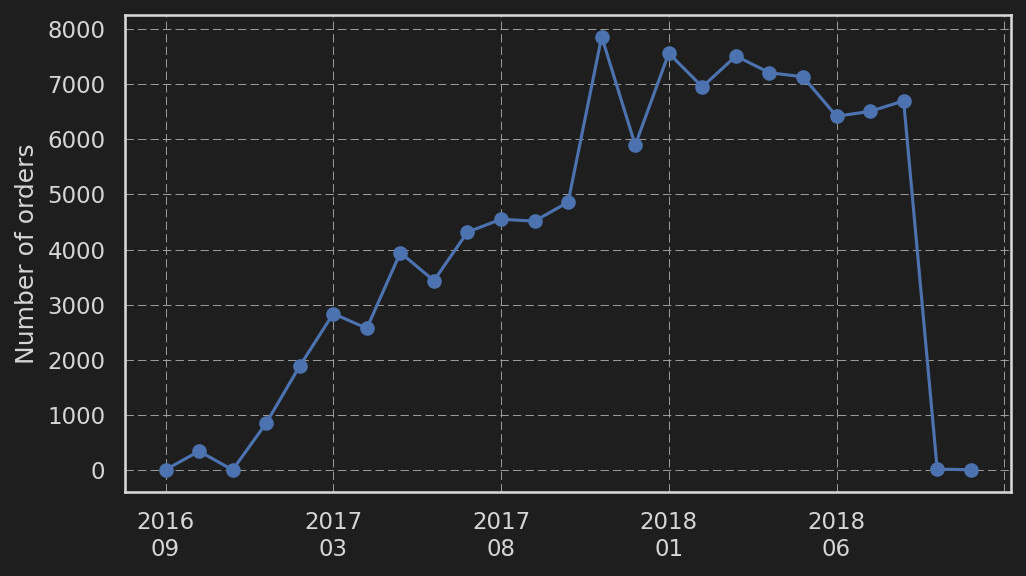

In [15]:
fig, ax = plt.subplots( figsize=(7,4) )
# df_merged['order_purchase_timestamp'].apply(lambda x: x.strftime('%Y\n%m') ).value_counts().sort_index().plot(kind='line', ax=ax, style='-o')
df_merged['order_purchase_timestamp'].dt.strftime('%Y\n%m').value_counts().sort_index().plot(kind='line', ax=ax, style='-o')
ax.set_ylabel( 'Number of orders')
fig.tight_layout()

In [16]:
df_merged.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 103887 entries, 0 to 103886
Data columns (total 16 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_id                       103887 non-null  object        
 1   customer_id                    103887 non-null  object        
 2   order_status                   103887 non-null  object        
 3   order_purchase_timestamp       103887 non-null  datetime64[ns]
 4   order_approved_at              103712 non-null  datetime64[ns]
 5   order_delivered_carrier_date   101999 non-null  datetime64[ns]
 6   order_delivered_customer_date  100755 non-null  datetime64[ns]
 7   order_estimated_delivery_date  103887 non-null  datetime64[ns]
 8   customer_unique_id             103887 non-null  object        
 9   customer_zip_code_prefix       103887 non-null  int64         
 10  customer_city                  103887 non-null  object        
 11  

In [17]:
df_merged['order_purchase_timestamp'].max()

Timestamp('2018-10-17 17:30:18')

In [42]:
print( 'customer_id :', df_merged['customer_id'].value_counts().shape ) 
print( 'customer_unique_id :', df_merged['customer_unique_id'].value_counts().shape )


groups = df_merged[['customer_unique_id',
                      'payment_value']].copy()
groups['number_of_days_since_last_order'] = (df_merged['order_purchase_timestamp'].max() - df_merged['order_purchase_timestamp']).dt.days

groups = groups.groupby( by='customer_unique_id' )

df_model = pd.DataFrame()
df_model['Recence'] = groups['number_of_days_since_last_order' ].max()
df_model['Frequence'] = groups['payment_value'].size()
df_model['Montant'] = groups['payment_value'].sum()

display( df_model.iloc[18:27,:] )

# df_model = df_model.groupby( by='customer_unique_id' ).agg( ['sum', 'size', 'max'] )
# display( df_model.iloc[18:27,:] )

# df_model_2 = pd.DataFrame()
# df_model_2[['montant', 'number_of_orders', 'number_of_days_since_last_order']] = df_model[ [('payment_value','sum'), ('payment_value', 'size'), ('number_of_days_since_last_order', 'max')]]
# df_model_2.iloc[18:27,:]

customer_id : (99441,)
customer_unique_id : (96096,)


,Recence,Frequence,Montant
customer_unique_id,,,
000de6019bb59f34c099a907c151d855,425,1,257.44
000e309254ab1fc5ba99dd469d36bdb4,114,2,78.42
000ec5bff359e1c0ad76a81a45cb598f,57,1,27.75
000ed48ceeb6f4bf8ad021a10a3c7b43,150,1,20.75
000fbf0473c10fc1ab6f8d2d286ce20c,83,1,362.38
0010a452c6d13139e50b57f19f52e04e,463,1,325.93
0010fb34b966d44409382af9e8fd5b77,226,1,61.80
001147e649a7b1afd577e873841632dd,412,1,212.16
00115fc7123b5310cf6d3a3aa932699e,633,1,76.11


,1,2,3,4,5,6,7,8,9,11,10,12,13,14,19,15,29,33,17,16,26,22,23
Frequence,90367,4801,554,163,68,51,30,14,11,7,6,6,4,3,2,2,1,1,1,1,1,1,1
%,94.038,4.996,0.577,0.17,0.071,0.053,0.031,0.015,0.011,0.007,0.006,0.006,0.004,0.003,0.002,0.002,0.001,0.001,0.001,0.001,0.001,0.001,0.001


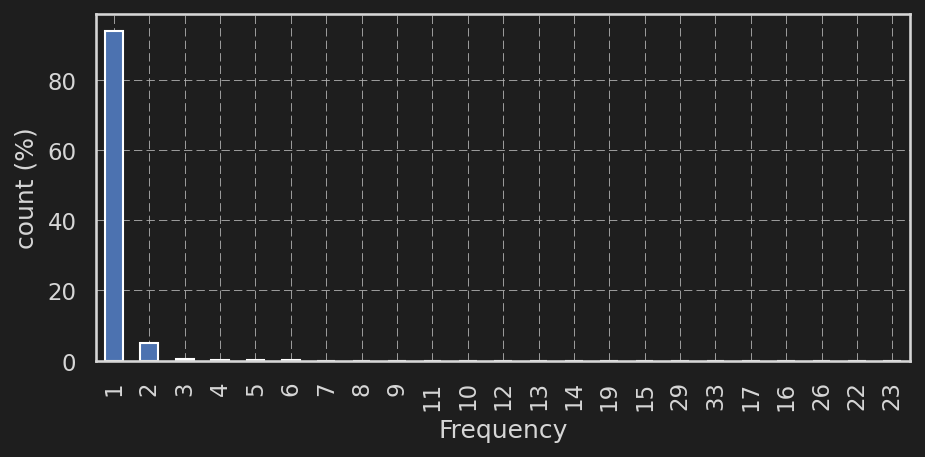

In [39]:
sr_freq = df_model['Frequence'].value_counts( )
df_freq = pd.DataFrame( sr_freq.astype(str) ) # str for display
sr_freq *= 100 / sr_freq.sum()
df_freq['%'] = sr_freq.values.round(3)
display( df_freq.T )


fig, ax = plt.subplots( figsize=(7,3) )
sr_freq.plot( kind='bar', ax=ax )
ax.set_xlabel('Frequency')
_ = ax.set_ylabel('count (%)')

array([<Axes: title={'center': 'Montant'}>], dtype=object)

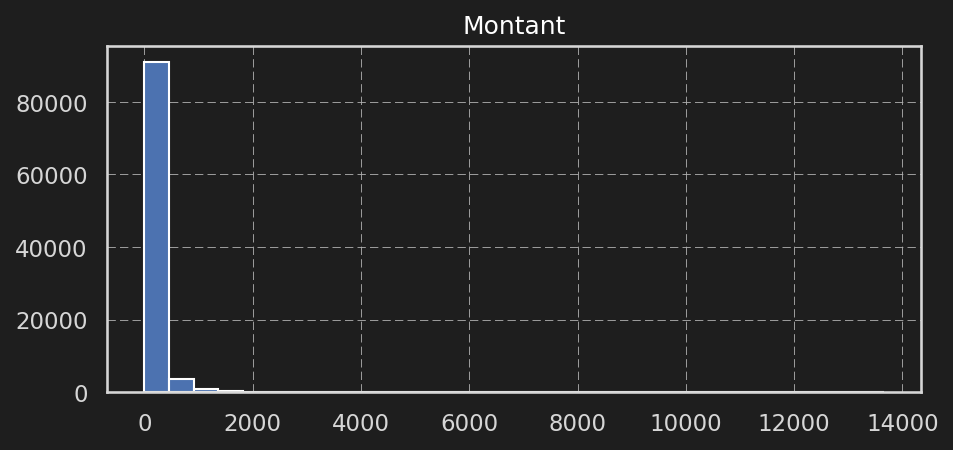

In [46]:
fig, ax = plt.subplots( figsize=(7,3) )

df_model.hist( column='Montant', bins=30, ax=ax )

array([<Axes: title={'center': 'Recence'}>], dtype=object)

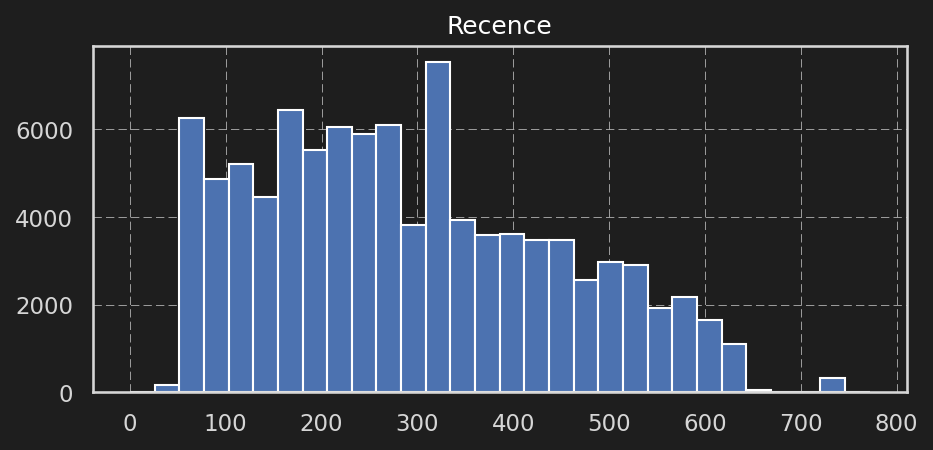

In [47]:
fig, ax = plt.subplots( figsize=(7,3) )

df_model.hist( column='Recence', bins=30, ax=ax )

Utilisation de quantiles

categories Frequence: Int64Index([1, 2, 3], dtype='int64')
categories Montant: Int64Index([1, 2, 3, 4], dtype='int64')
categories Recence: Int64Index([1, 2, 3], dtype='int64')


[]

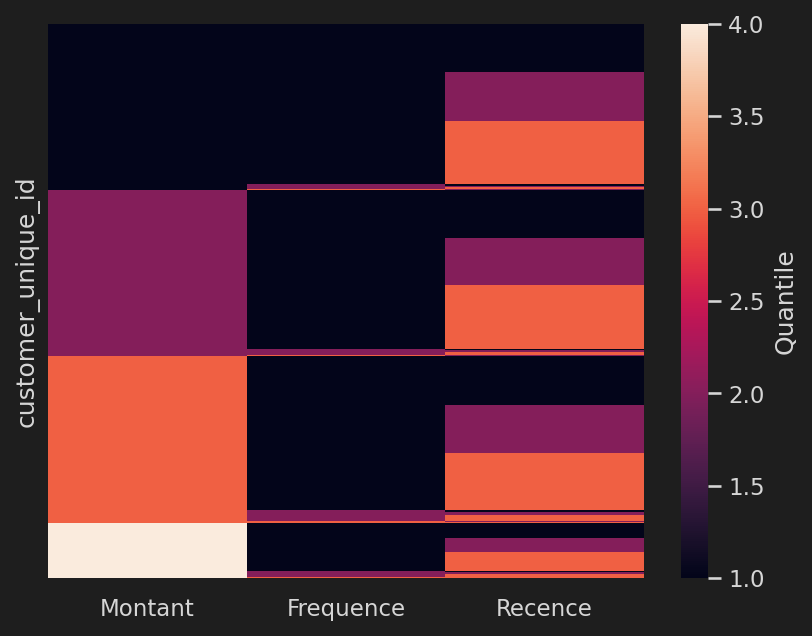

In [84]:
df_quantiles = df_model.copy()

# Frequence
key = 'Frequence'
# loc = df_quantiles[key] != 1
# sr = df_quantiles.loc[loc,key]
# print('sr:', sr.min(), sr.max())
# print( sr.quantile([0.3, 0.9]) )
# categs = np.digitize( sr.values,bins=sr.quantile([0.3, 0.6]))
# print( categs.min(), categs.max() )
# df_quantiles.loc[loc,key] = np.digitize( df_quantiles.loc[loc,key].values,bins=[3])

# On laisse les valeurs 1 et 2 telles quelles, les autres (> 2) sont en catégorie 3
df_quantiles.loc[ df_quantiles[key]>2, key] = 3
df_quantiles[key] = df_quantiles[key].astype('category')
print( f'categories {key}:', df_quantiles[key].cat.categories )


key = 'Montant'
quantiles = df_quantiles[key].quantile( [0.3, 0.6, 0.9])
# print(quantiles)
categs = np.digitize( df_quantiles[key].values, bins=quantiles )
# print('categs:', categs.min(), categs.max() )
df_quantiles[key] = 1 + categs
df_quantiles[key] = df_quantiles[key].astype('category')
print( f'categories {key}:', df_quantiles[key].cat.categories )


key = 'Recence'
quantiles = df_quantiles[key].quantile( [0.3, 0.6])
# print(quantiles)
categs = np.digitize( df_quantiles[key].values, bins=quantiles )
# print('categs:', categs.min(), categs.max() )
df_quantiles[key] = 1 + categs
df_quantiles[key] = df_quantiles[key].astype('category')
print( f'categories {key}:', df_quantiles[key].cat.categories )

# sort_order = ['Frequence', 'Recence', 'Montant']
sort_order = ['Montant','Frequence', 'Recence']
ax = sns.heatmap( df_quantiles[sort_order].sort_values( by=sort_order ) ,
            cbar_kws={'label': 'Quantile'})
ax.set_yticks([])

---

## PCA

In [20]:
df_model_2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 96096 entries, 0000366f3b9a7992bf8c76cfdf3221e2 to ffffd2657e2aad2907e67c3e9daecbeb
Data columns (total 3 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   montant                          96096 non-null  float64
 1   number_of_orders                 96096 non-null  int64  
 2   number_of_days_since_last_order  96096 non-null  int64  
dtypes: float64(1), int64(2)
memory usage: 2.9+ MB


In [21]:
X = df_model_2.values
indexes = df_model_2.index
features = df_model_2.columns

print('\nX:', X.shape)
print('features:', features)


X: (96096, 3)
features: Index(['montant', 'number_of_orders', 'number_of_days_since_last_order'], dtype='object')


In [25]:
from sklearn.decomposition import PCA

scaler_pca = preprocessing.StandardScaler()
X_scaled = scaler_pca.fit_transform(X) # fit and transform

# Vérification moyenne et écart type
idx = ["mean", "std"]
display( pd.DataFrame(X_scaled).describe().round(2).loc[idx, :] )

n_components = X.shape[1]
pca = PCA(n_components=n_components)

# entrainement
pca.fit(X_scaled)

,0,1,2
mean,-0.0,0.0,0.0
std,1.0,1.0,1.0


PCA(n_components=3)

---

In [219]:
loc = df_merged['order_status'] == 'delivered'

key = 'delivery_time'
df_merged[key] = np.nan
df_merged.loc[ loc, key ] = df_merged.loc[ loc, 'order_delivered_customer_date' ] - df_merged.loc[ loc, 'order_purchase_timestamp' ]

key = 'estimated_delivery_time'
df_merged[key] = np.nan
df_merged.loc[ loc, key ] = df_merged.loc[ loc, 'order_estimated_delivery_date' ] - df_merged.loc[ loc, 'order_purchase_timestamp' ]

key = 'delivery_delay'
df_merged[key] = np.nan
df_merged.loc[ loc, key ] = df_merged.loc[ loc, 'delivery_time' ] - df_merged.loc[ loc, 'estimated_delivery_time']

In [220]:
tmp = df_merged.sort_values( by='delivery_time' ).head(10)
tmp

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,delivery_time,estimated_delivery_time,delivery_delay
31522,1d893dd7ca5f77ebf5f59f0d2017eee0,b19da0df0271e8a3553e3670f86aeab5,delivered,2017-06-19 08:19:45,2017-06-19 08:30:20,2017-06-19 13:32:04,2017-06-19 21:07:52,2017-06-30,adfcd54789b345d7242847c583b483cf,22723,rio de janeiro,RJ,0 days 12:48:07,10 days 15:40:15,-11 days +21:07:52
41803,434cecee7d1a65fc65358a632b6f725f,922a46283625e9c096bfd998913c470c,delivered,2017-05-29 13:21:46,2017-05-29 13:30:24,2017-05-29 14:54:51,2017-05-30 08:06:56,2017-06-19,781f80ac54444e4020dc3f70f044d8b3,3206,sao paulo,SP,0 days 18:45:10,20 days 10:38:14,-20 days +08:06:56
38792,f3c6775ba3d2d9fe2826f93b71f12008,6aef84c09844a371d82a49152c550b95,delivered,2017-07-04 11:37:47,2017-07-04 11:50:21,2017-07-04 13:53:13,2017-07-05 08:09:26,2017-07-17,c4320fbd4bc46bc041e8c2b703a05cd6,11410,guaruja,SP,0 days 20:31:39,12 days 12:22:13,-12 days +08:09:26
97428,8339b608be0d84fca9d8da68b58332c3,ff58662c328f81d3ee549c9caa942f39,delivered,2018-06-26 20:48:33,2018-06-26 21:07:25,2018-06-27 11:31:00,2018-06-27 17:31:53,2018-07-25,13071413b2d7b730db1cd98a4611f2b2,45810,porto seguro,BA,0 days 20:43:20,28 days 03:11:27,-28 days +17:31:53
69580,bb5a519e352b45b714192a02ffe25681,118295a853acb536efff13740faf5be8,delivered,2017-05-31 11:11:55,2017-05-31 11:22:55,2017-05-31 11:36:15,2017-06-01 08:34:36,2017-06-27,a0fea4478b5357571900273006dd7cd6,5813,sao paulo,SP,0 days 21:22:41,26 days 12:48:05,-26 days +08:34:36
51067,e65f1eeee1f52024ad1dcd03447f7482,198f511b5a75bf936a96f1d4769e3974,delivered,2018-05-18 15:03:19,2018-05-18 15:15:37,2018-05-18 15:00:00,2018-05-19 12:28:30,2018-05-29,d5f0cd2eb93b7fc7c2350e758af16dc9,9120,santo andre,SP,0 days 21:25:11,10 days 08:56:41,-10 days +12:28:30
37753,21a8ffca665bc7a1087d31751a7b7cbc,225aed9e773953084b09cf496c2be05a,delivered,2017-05-31 12:00:35,2017-05-31 13:07:28,2017-05-31 12:43:47,2017-06-01 10:28:24,2017-06-13,92776276a13b6d52820b4014aa07250d,1547,sao paulo,SP,0 days 22:27:49,12 days 11:59:25,-12 days +10:28:24
48878,d5fbeedc85190ba88580d6f82d1d5ed3,344423c2e26d47d2b6d3dd363a89e812,delivered,2017-05-15 11:50:53,2017-05-15 12:12:07,2017-05-15 12:52:34,2017-05-16 10:21:52,2017-05-24,6ebecf9718a9fdd2d34ea36f36501420,9950,diadema,SP,0 days 22:30:59,8 days 12:09:07,-8 days +10:21:52
48767,f349cdb62f69c3fae5c4d7d3f3a4a185,c5e200d485ae35a7036cc2e7c1d8ea81,delivered,2018-06-28 14:34:48,2018-06-28 14:50:48,2018-06-28 18:08:00,2018-06-29 14:12:18,2018-07-12,938e4b10f5b5ca81ab31b7c89367c559,13087,campinas,SP,0 days 23:37:30,13 days 09:25:12,-13 days +14:12:18
395,38c1e3d4ed6a13cd0cf612d4c09766e9,18c934f4cdc994cd04eb13bce3f47a18,delivered,2018-02-02 15:26:38,2018-02-02 16:00:16,2018-02-03 01:18:26,2018-02-03 15:05:56,2018-02-20,9aa5b032a9157594cda43b16a832f738,8260,sao paulo,SP,0 days 23:39:18,17 days 08:33:22,-17 days +15:05:56


In [221]:
X, Y = 'delivery_time', 'delivery_delay'
x = df_merged.loc[ loc, X ]
display( x.sort_values() )
x = np.array([xi.value for xi in x]) / (3600 * 24 * 1e9)

argmin = x.argmin()
print( x[argmin] )
print( df_merged.loc[loc, :].iloc[argmin,:] )
print( df_merged.loc[loc, :].iloc[argmin,:].isna() )

31522   0 days 12:48:07
41803   0 days 18:45:10
38792   0 days 20:31:39
97428   0 days 20:43:20
69580   0 days 21:22:41
              ...      
79263               NaT
82868               NaT
92643               NaT
97647               NaT
98038               NaT
Name: delivery_time, Length: 96478, dtype: timedelta64[ns]

-106751.99116730064
order_id                         2d1e2d5bf4dc7227b3bfebb81328c15f
customer_id                      ec05a6d8558c6455f0cbbd8a420ad34f
order_status                                            delivered
order_purchase_timestamp                      2017-11-28 17:44:07
order_approved_at                             2017-11-28 17:56:40
order_delivered_carrier_date                  2017-11-30 18:12:23
order_delivered_customer_date                                 NaT
order_estimated_delivery_date                 2017-12-18 00:00:00
customer_unique_id               13467e882eb3a701826435ee4424f2bd
customer_zip_code_prefix                                    18520
customer_city                                           cerquilho
customer_state                                                 SP
delivery_time                                                 NaT
estimated_delivery_time                          19 days 06:15:53
delivery_delay                                          

2.0080092592592593
155.13546296296298
-134.78411324786325
174.43853632478633


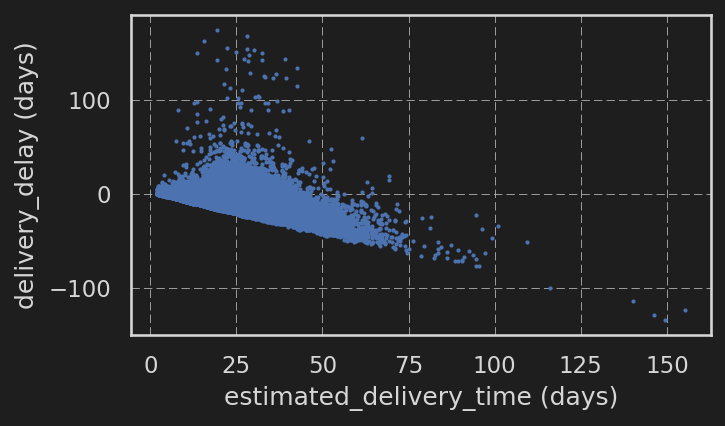

In [225]:
X, Y = 'estimated_delivery_time', 'delivery_delay'

fig, ax = plt.subplots( figsize=(5,3) )
x = df_merged.loc[ loc,  X ]
y = df_merged.loc[ loc,  Y ]

loc2 = ~(x.isna() | y.isna() )
x = x.loc[loc2]
y = y.loc[loc2]
                                            # ns to day
x = np.array([xi.value for xi in x]) / (3600 * 24 * 1e9)
y = np.array([yi.value for yi in y]) / (3600 * 26 * 1e9)

print( x.min( ))
print( x.max( ))
print( y.min( ))
print( y.max( ))


ax.plot( x, y, 'o', markersize=1 )
ax.set_xlabel( f'{X} (days)' )
ax.set_ylabel( f'{Y} (days)' )
fig.tight_layout()

In [49]:
df = dfs['orders'][['order_id', 'customer_id']].copy()

tmp = dfs['customers']['customer_id']
tmp2 = dfs['customers']['customer_unique_id']


df['customer_unique_id'] = [ tmp2.loc[ tmp == customer_id ] for customer_id in df['customer_id'] ]

print('df :', df.shape)
print( 'different customer_id :', df['customer_id'].value_counts().shape )
print( 'different customer_unique_id :', df['customer_unique_id'].value_counts().shape )

KeyboardInterrupt: 

---

In [ ]:
df = dfs['order_items']
print('order_items :', df.shape)
display( df.head() )

order_items : (112650, 7)


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [ ]:
df = dfs['order_reviews']
print('order_reviews :', df.shape)
display( df.head() )

order_reviews : (99224, 7)


,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


order_payments: (103886, 5)


,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


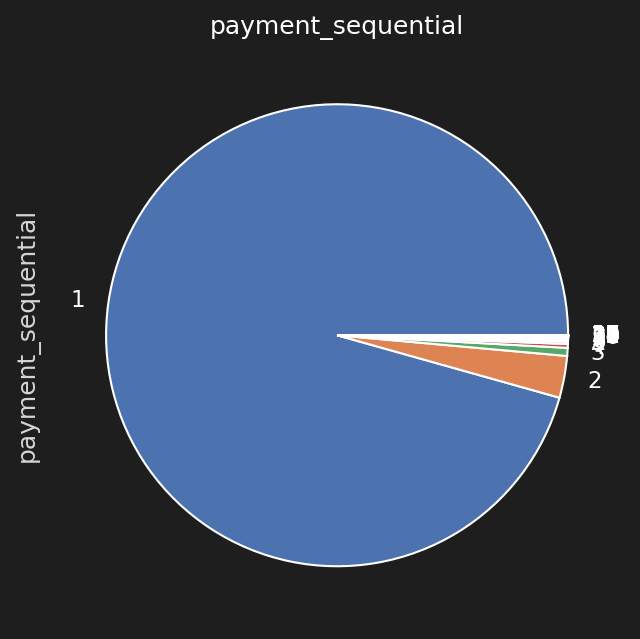

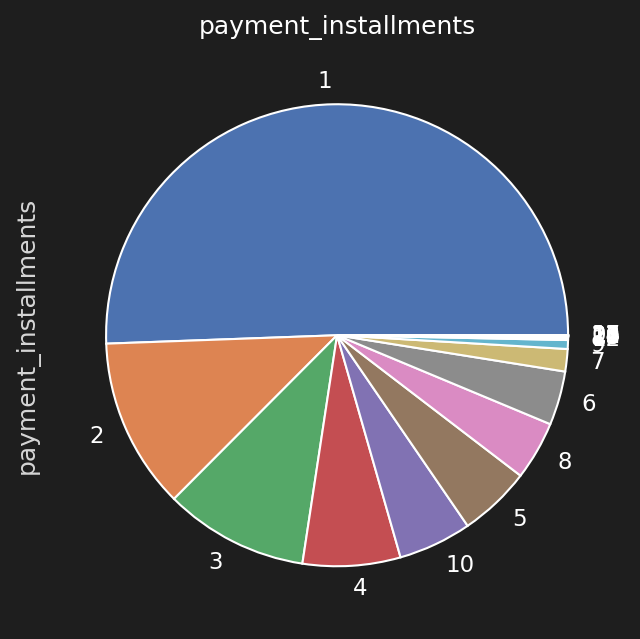

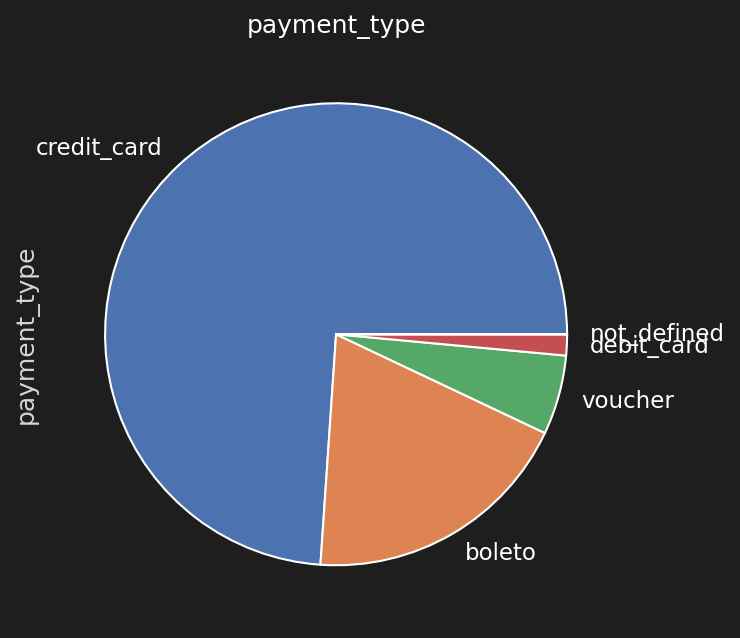

In [ ]:
df = dfs['order_payments']
print('order_payments:', df.shape)
display( df.head() )

for key in ['payment_sequential', 'payment_installments', 'payment_type' ]:
    fig, ax = plt.subplots( figsize=(5,5) )
    df[key].value_counts( normalize=True ).plot( kind='pie' )
    ax.set_title( key )